# 06_NLI_data - Train / val / test split for NLI fine-tuning

Builds the sentence-pair CSVs consumed by `06_NLI_finetune_ContraDoc.ipynb` (training) and `06_NLI_ContraDoc.ipynb` (eval). Pairs come from ContraDoc directly (not the LLM extraction); each YES doc contributes one or more `(evidence, ref)` positives plus `NEG_PER_POS` random in-doc negatives.

## Pool design (relaxed: in-domain fine-tuning)

- **Test = balanced 150** (the canonical sample built in notebook 01) - downstream pipeline eval set, also the source of `chunk_candidates.jsonl`.
- **Train + Val = usable YES docs whose `doc_id` is NOT in balanced 150**.

The pool admits docs whose `base_doc_id` is shared with a balanced doc but whose specific `doc_id` is not. Concretely: `3488771854_6` may be in test while `3488771854_8` lands in train. Both share the same source play but carry **different injected contradictions** - the NLI task is to detect the contradiction in each variant, and the contradicting `(evidence, ref)` pair is unique per variant.

## What this is and isn't

- This **is** in-domain fine-tuning: the model sees source-text patterns at train time that it'll see again at test time, but the *labelled contradiction pairs* and exact `doc_id`s are disjoint between splits.
- This **is not** an out-of-distribution evaluation. If you want to claim "the model generalizes to entirely new sources," use the strict `base_doc_id`-disjoint variant from the legacy `nli_finetune_data.ipynb`.

## Leakage discipline retained

- **Strict `doc_id` disjointness** between train, val, test (asserted at runtime).
- **Within-doc pair construction only** - no example carries text from another doc; pairs cannot cross splits.

**Output:** `data/processed/ContraDoc/nli/{nli_train.csv, nli_val.csv, nli_test.csv, nli_splits.json}`.


In [1]:
import json
import re
from collections import Counter, defaultdict
from difflib import SequenceMatcher
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit


In [2]:
N_TRAIN_FRAC = 0.85   # within the train+val pool; rest goes to val
NEG_PER_POS = 4       # in-doc random negatives per gold positive pair
SEED = 42

DATA_DIR = Path("data/processed/ContraDoc")
INPUT_CSV = DATA_DIR / "ContraDoc.csv"
BALANCED_PATH = DATA_DIR / "balanced_sample.json"
FINDABILITY_PATH = DATA_DIR / "findability.json"
OUT_DIR = DATA_DIR / "nli"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR = Path("plots/06_NLI_data")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 15,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
C_BLUE, C_RED, C_GREEN, C_PURPLE, C_YELLOW = "#4C72B0", "#C44E52", "#55A868", "#8172B2", "#CCB974"


## Load inputs

In [3]:
df = pd.read_csv(INPUT_CSV)
balanced = json.loads(BALANCED_PATH.read_text(encoding="utf-8"))
findability = json.loads(FINDABILITY_PATH.read_text(encoding="utf-8"))

balanced_doc_ids = set(balanced["doc_ids"])
print(f"balanced sample size: {len(balanced_doc_ids)} docs")

# doc_id -> base_doc_id map
doc_to_base: dict[str, str] = {}
for base, variants in findability["yes_base_doc_groups"].items():
    for did in variants:
        doc_to_base[did] = base

# usable YES pool from findability + drop docs containing 'Other' primitive
usable_doc_ids = set(findability["usable_doc_ids"])
yes_usable = df[df["id"].astype(str).isin(usable_doc_ids)].copy()
yes_usable["base_doc_id"] = yes_usable["id"].astype(str).map(doc_to_base)

EXCLUDED = frozenset({"Other"})
yes_usable = yes_usable[
    ~yes_usable["contra_type"].fillna("").map(
        lambda s: bool(set(t.strip() for t in str(s).split("|") if t.strip()) & EXCLUDED)
    )
].reset_index(drop=True)

print(f"usable YES pool (after dropping {sorted(EXCLUDED)}): {len(yes_usable)} docs")
print(f"  unique base_doc_ids: {yes_usable['base_doc_id'].nunique()}")


balanced sample size: 150 docs
usable YES pool (after dropping ['Other']): 301 docs
  unique base_doc_ids: 169


## Build train+val and test pools (doc_id-disjoint)

The relaxation: train+val pool admits any usable YES doc whose `doc_id` is not in the balanced 150. Variants of bases that ARE in balanced are still eligible - they carry different injected contradictions and provide in-domain training signal.

In [4]:
# TEST = balanced 150 exactly
test_df = yes_usable[yes_usable["id"].astype(str).isin(balanced_doc_ids)].copy()
test_df["split"] = "test"

# TRAIN+VAL pool = usable YES docs whose doc_id is NOT in balanced
trainval_pool = yes_usable[~yes_usable["id"].astype(str).isin(balanced_doc_ids)].copy()
print(f"train+val candidate pool: {len(trainval_pool)} docs ({trainval_pool['base_doc_id'].nunique()} bases)")

# How much did relaxation gain us?
balanced_bases = set(test_df["base_doc_id"])
strict_pool = trainval_pool[~trainval_pool["base_doc_id"].isin(balanced_bases)]
gained = len(trainval_pool) - len(strict_pool)
print(f"  vs strict base_doc_id-disjoint policy: {len(strict_pool)} docs (+{gained} gained by relaxation)")


train+val candidate pool: 151 docs (110 bases)
  vs strict base_doc_id-disjoint policy: 74 docs (+77 gained by relaxation)


## Sentence-level helpers

In [5]:
_SENT_SPLIT_RE = re.compile(r"(?<=[.!?])\s+")


def _normalize(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip().lower().rstrip(".!?\"'")


def split_sentences(text: str) -> list[str]:
    return [s for s in _SENT_SPLIT_RE.split(text) if s.strip()]


def find_sentence_idx(target: str, sentences: list[str], threshold: float = 0.85) -> int:
    """Return 0-based sentence index whose normalized text best matches target,
    or -1 if no match meets threshold."""
    t_norm = _normalize(target)
    for i, s in enumerate(sentences):
        s_n = _normalize(s)
        if t_norm and (s_n == t_norm or t_norm in s_n):
            return i
    best_idx, best_score = -1, 0.0
    for i, s in enumerate(sentences):
        score = SequenceMatcher(None, _normalize(s), t_norm).ratio()
        if score > best_score:
            best_idx, best_score = i, score
    return best_idx if best_score >= threshold else -1


## Group-aware train/val split inside the train+val pool

We still group by `base_doc_id` for the *train* vs *val* split so a single base's variants don't straddle the train/val boundary - that boundary matters for early-stopping fairness. But base_doc_ids ARE allowed to overlap with the test pool's bases (that's the whole point of the relaxation).

In [6]:
groups_arr = trainval_pool["base_doc_id"].to_numpy()
gss = GroupShuffleSplit(n_splits=1, test_size=1 - N_TRAIN_FRAC, random_state=SEED)
train_local, val_local = next(gss.split(trainval_pool, groups=groups_arr))

train_df = trainval_pool.iloc[train_local].copy()
train_df["split"] = "train"
val_df = trainval_pool.iloc[val_local].copy()
val_df["split"] = "val"

split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print("doc-level split:")
print(split_df["split"].value_counts().to_string())
print()

# LEAKAGE ASSERTIONS
train_doc_ids = set(train_df["id"].astype(str))
val_doc_ids   = set(val_df["id"].astype(str))
test_doc_ids  = set(test_df["id"].astype(str))
assert train_doc_ids.isdisjoint(test_doc_ids), f"LEAKAGE: train cap test doc_ids = {train_doc_ids & test_doc_ids}"
assert val_doc_ids.isdisjoint(test_doc_ids),   f"LEAKAGE: val cap test doc_ids = {val_doc_ids & test_doc_ids}"
assert train_doc_ids.isdisjoint(val_doc_ids),  f"LEAKAGE: train cap val doc_ids = {train_doc_ids & val_doc_ids}"

# Inner train/val base disjointness (still strict for early-stopping fairness)
train_bases = set(train_df["base_doc_id"])
val_bases   = set(val_df["base_doc_id"])
assert train_bases.isdisjoint(val_bases), f"LEAKAGE: train cap val bases = {train_bases & val_bases}"

# Train/test base disjoint? Report but do not enforce.
test_bases = set(test_df["base_doc_id"])
shared_bases_with_test = (train_bases | val_bases) & test_bases
print("doc_id-disjoint: train cap test = empty, val cap test = empty (asserted)")
print("  train cap val bases: empty (asserted, for early-stopping fairness)")
print(f"  (train|val) cap test BASES: {len(shared_bases_with_test)} shared (allowed under in-domain policy)")


doc-level split:
split
test     150
train    121
val       30

doc_id-disjoint: train cap test = empty, val cap test = empty (asserted)
  train cap val bases: empty (asserted, for early-stopping fairness)
  (train|val) cap test BASES: 47 shared (allowed under in-domain policy)


## Build sentence-pair examples

In [7]:
def make_pairs_for_doc(row: pd.Series, neg_per_pos: int, rng: np.random.Generator) -> list[dict]:
    text = row["text"]
    sentences = split_sentences(text)
    n = len(sentences)
    if n < 2:
        return []

    evidence = row["evidence"]
    refs = [r for r in str(row["ref_sentences"]).split("|") if r.strip()]
    e_idx = find_sentence_idx(evidence, sentences)
    r_idxs = [find_sentence_idx(r, sentences) for r in refs]
    r_idxs = [i for i in r_idxs if i >= 0]
    if e_idx < 0 or not r_idxs:
        return []

    pairs: list[dict] = []
    excluded: set[tuple[int, int]] = set()

    for r_idx in r_idxs:
        if r_idx == e_idx:
            continue
        a, b = (e_idx, r_idx) if e_idx < r_idx else (r_idx, e_idx)
        excluded.add((a, b))
        pairs.append({
            "premise": sentences[e_idx],
            "hypothesis": sentences[r_idx],
            "label": 1,
            "kind": "gold",
            "premise_idx": e_idx,
            "hypothesis_idx": r_idx,
        })

    all_pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]
    neg_pool = [p for p in all_pairs if p not in excluded]
    n_neg_target = min(neg_per_pos * len(r_idxs), len(neg_pool))
    if n_neg_target == 0:
        return pairs

    chosen_pos = rng.choice(len(neg_pool), size=n_neg_target, replace=False)
    for ci in chosen_pos:
        i, j = neg_pool[int(ci)]
        if rng.random() < 0.5:
            p_idx, h_idx = i, j
        else:
            p_idx, h_idx = j, i
        pairs.append({
            "premise": sentences[p_idx],
            "hypothesis": sentences[h_idx],
            "label": 0,
            "kind": "in_doc_negative",
            "premise_idx": p_idx,
            "hypothesis_idx": h_idx,
        })
    return pairs


rng = np.random.default_rng(SEED)
records: list[dict] = []
skipped: list[str] = []
pair_id = 0
for _, row in split_df.iterrows():
    pairs = make_pairs_for_doc(row, NEG_PER_POS, rng)
    if not pairs:
        skipped.append(str(row["id"]))
        continue
    for p in pairs:
        records.append({
            "pair_id": pair_id,
            "doc_id": str(row["id"]),
            "base_doc_id": row["base_doc_id"],
            "split": row["split"],
            "contra_type": row["contra_type"],
            **p,
        })
        pair_id += 1

pairs_df = pd.DataFrame(records)
print(f"generated {len(pairs_df)} pairs from {split_df['id'].nunique() - len(skipped)} docs")
if skipped:
    print(f"  skipped {len(skipped)} docs (couldnt sentence-locate evidence/refs); first 5: {skipped[:5]}")
print()
print("per-split, per-label counts:")
print(pairs_df.groupby(["split", "label"]).size().unstack(fill_value=0).to_string())


generated 1328 pairs from 264 docs
  skipped 37 docs (couldnt sentence-locate evidence/refs); first 5: ['3488771840_10', '3488771860_5', '3488771876_2', '3488771888_8', '3488771891_7']

per-split, per-label counts:
label    0    1
split          
test   564  103
train  444   90
val    104   23


## Persist CSVs and split metadata

In [8]:
for split_name in ("train", "val", "test"):
    sub = pairs_df[pairs_df["split"] == split_name].drop(columns=["split"])
    out_path = OUT_DIR / f"nli_{split_name}.csv"
    sub.to_csv(out_path, index=False)
    n_pos = int((sub["label"] == 1).sum())
    n_neg = int((sub["label"] == 0).sum())
    print(f"  {split_name}: {len(sub):>5} pairs (pos={n_pos}, neg={n_neg})  -> {out_path}")

split_payload = {
    "seed": SEED,
    "design": "in_domain_doc_id_disjoint",
    "description": (
        "Test = balanced 150 doc_ids exactly. Train+val = usable YES docs whose doc_id is NOT in balanced. "
        "Bases CAN overlap with test (in-domain fine-tuning); only doc_id-level pairs differ. Train/val "
        "split inside the leftover pool by GroupShuffleSplit on base_doc_id (early-stopping fairness)."
    ),
    "train_frac_within_leftover": N_TRAIN_FRAC,
    "neg_per_pos": NEG_PER_POS,
    "group_key": "base_doc_id",
    "leakage_strategy": (
        "train_doc_ids, val_doc_ids, test_doc_ids are pairwise disjoint (asserted at runtime). "
        "train_bases vs val_bases is disjoint (asserted, for early-stopping fairness). "
        "train_bases vs test_bases is NOT enforced disjoint - this is intentional in-domain fine-tuning."
    ),
    "doc_id_split": {
        s: sorted(split_df[split_df["split"] == s]["id"].astype(str).tolist())
        for s in ("train", "val", "test")
    },
    "base_doc_id_split": {
        s: sorted(split_df[split_df["split"] == s]["base_doc_id"].unique().tolist())
        for s in ("train", "val", "test")
    },
    "pair_counts": {
        s: {
            "pos": int(((pairs_df["split"] == s) & (pairs_df["label"] == 1)).sum()),
            "neg": int(((pairs_df["split"] == s) & (pairs_df["label"] == 0)).sum()),
            "total": int((pairs_df["split"] == s).sum()),
        }
        for s in ("train", "val", "test")
    },
    "skipped_doc_ids": skipped,
}
(OUT_DIR / "nli_splits.json").write_text(
    json.dumps(split_payload, indent=2, ensure_ascii=False), encoding="utf-8"
)
print()
print(f"saved metadata: {OUT_DIR / 'nli_splits.json'}")


  train:   534 pairs (pos=90, neg=444)  -> data\processed\ContraDoc\nli\nli_train.csv
  val:   127 pairs (pos=23, neg=104)  -> data\processed\ContraDoc\nli\nli_val.csv
  test:   667 pairs (pos=103, neg=564)  -> data\processed\ContraDoc\nli\nli_test.csv

saved metadata: data\processed\ContraDoc\nli\nli_splits.json


## Plots

Visualize split sizes, label balance, and per-contra-type coverage. PNGs saved to `plots/06_NLI_data/`.

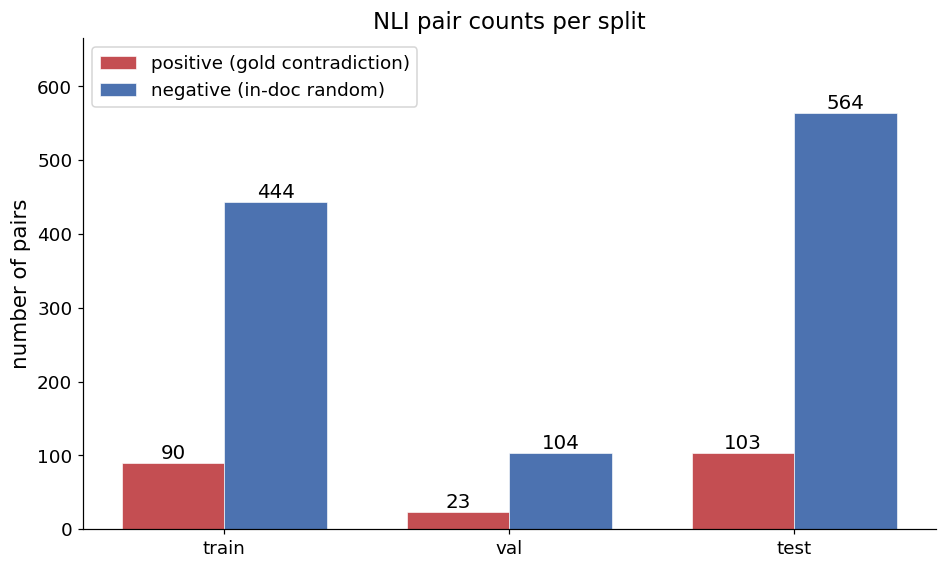

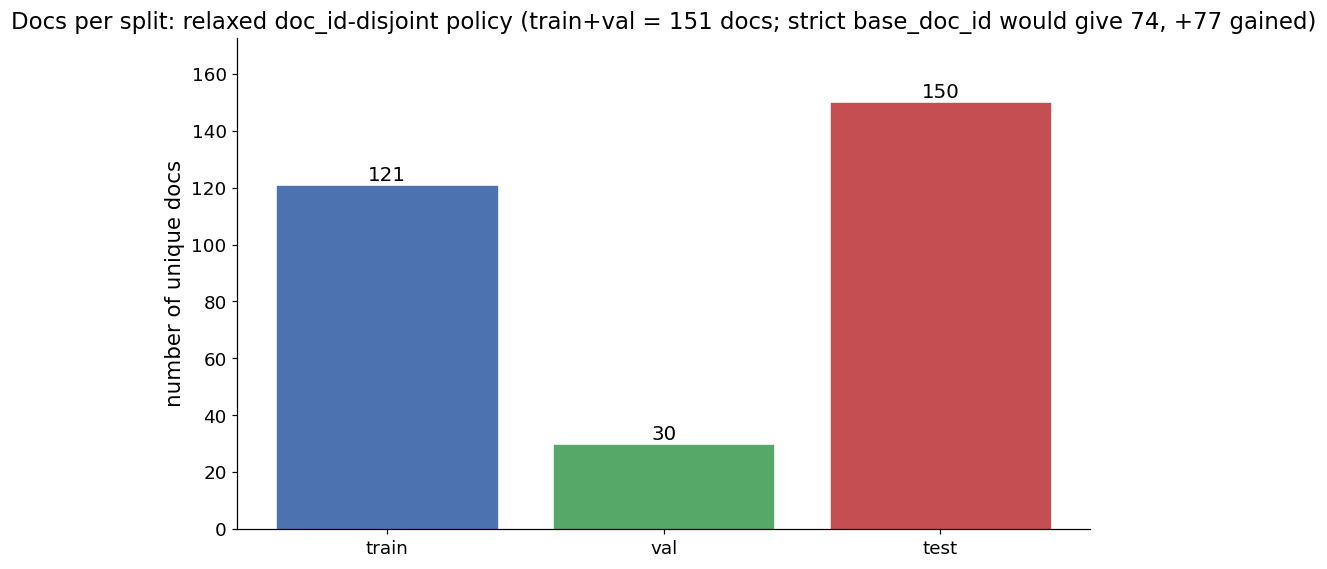

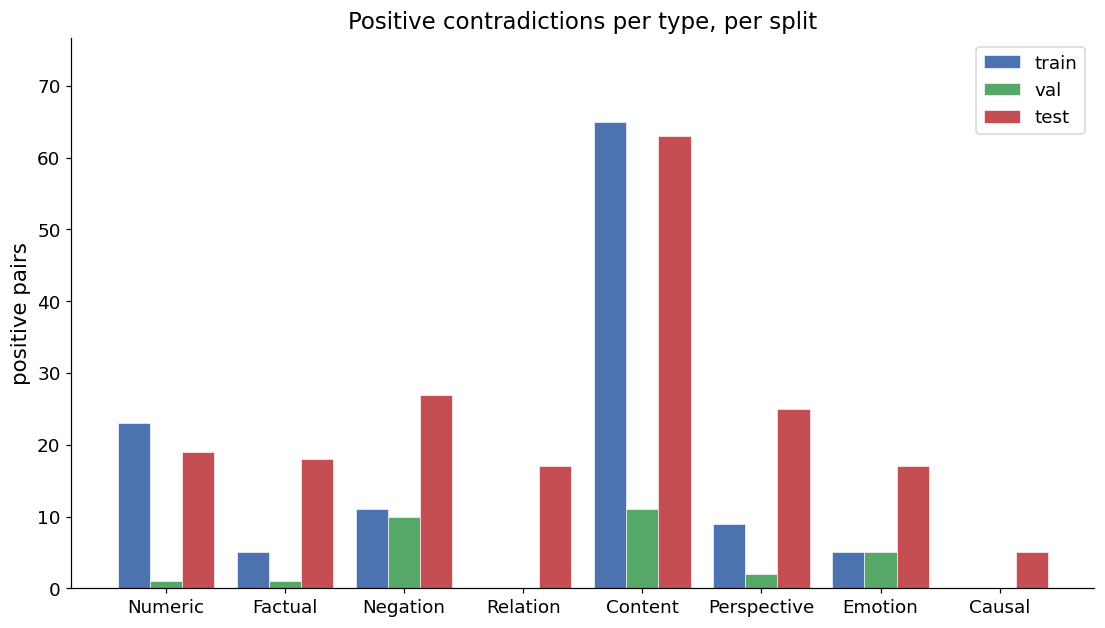

Saved 3 plots to D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\plots\06_NLI_data


In [9]:
# --- Plot 1: pair counts per split (positive vs negative) ---
splits = ["train", "val", "test"]
pos_counts = [int(((pairs_df["split"] == s) & (pairs_df["label"] == 1)).sum()) for s in splits]
neg_counts = [int(((pairs_df["split"] == s) & (pairs_df["label"] == 0)).sum()) for s in splits]
x = np.arange(len(splits))
w = 0.36
fig, ax = plt.subplots(figsize=(10, 5.8))
b1 = ax.bar(x - w/2, pos_counts, w, label="positive (gold contradiction)", color=C_RED, edgecolor="white", linewidth=0.4)
b2 = ax.bar(x + w/2, neg_counts, w, label="negative (in-doc random)",   color=C_BLUE, edgecolor="white", linewidth=0.4)
for b, v in zip(b1, pos_counts):
    ax.text(b.get_x() + b.get_width()/2, v, str(v), ha="center", va="bottom")
for b, v in zip(b2, neg_counts):
    ax.text(b.get_x() + b.get_width()/2, v, str(v), ha="center", va="bottom")
ax.set_xticks(x); ax.set_xticklabels(splits)
ax.set_ylabel("number of pairs")
ax.set_title("NLI pair counts per split")
ax.set_ylim(0, max(neg_counts) * 1.18)
ax.legend(loc="upper left")
fig.savefig(PLOT_DIR / "split_pair_counts.png")
plt.show()

# --- Plot 2: docs per split (relaxed vs strict comparison) ---
docs_per_split = [int(split_df[split_df["split"] == s]["id"].nunique()) for s in splits]
strict_train_val = int((~yes_usable["id"].astype(str).isin(balanced_doc_ids) & ~yes_usable["base_doc_id"].isin(balanced_bases)).sum())
fig, ax = plt.subplots(figsize=(10, 5.8))
ax.bar(splits, docs_per_split, color=[C_BLUE, C_GREEN, C_RED], edgecolor="white", linewidth=0.4)
for i, v in enumerate(docs_per_split):
    ax.text(i, v, str(v), ha="center", va="bottom")
ax.set_ylabel("number of unique docs")
ax.set_title(
    f"Docs per split: relaxed doc_id-disjoint policy "
    f"(train+val = {docs_per_split[0] + docs_per_split[1]} docs; strict base_doc_id "
    f"would give {strict_train_val}, +{docs_per_split[0] + docs_per_split[1] - strict_train_val} gained)"
)
ax.set_ylim(0, max(docs_per_split) * 1.15)
fig.savefig(PLOT_DIR / "docs_per_split.png")
plt.show()

# --- Plot 3: positives per contra_type per split ---
def pos_by_type(split_name):
    sub = pairs_df[(pairs_df["split"] == split_name) & (pairs_df["label"] == 1)]
    counter = Counter()
    for ct in sub["contra_type"].fillna(""):
        for t in str(ct).split("|"):
            t = t.strip()
            if t:
                counter[t] += 1
    return counter

types_order = ["Numeric", "Factual", "Negation", "Relation", "Content", "Perspective/View/Opinion", "Emotion/Mood/Feeling", "Causal"]
short = {"Perspective/View/Opinion": "Perspective", "Emotion/Mood/Feeling": "Emotion"}
train_t = pos_by_type("train")
val_t   = pos_by_type("val")
test_t  = pos_by_type("test")
x = np.arange(len(types_order))
w = 0.27
train_vals = [train_t.get(t, 0) for t in types_order]
val_vals   = [val_t.get(t, 0)   for t in types_order]
test_vals  = [test_t.get(t, 0)  for t in types_order]
fig, ax = plt.subplots(figsize=(12, 6.5))
ax.bar(x - w, train_vals, w, label="train", color=C_BLUE, edgecolor="white", linewidth=0.4)
ax.bar(x,     val_vals,   w, label="val",   color=C_GREEN, edgecolor="white", linewidth=0.4)
ax.bar(x + w, test_vals,  w, label="test",  color=C_RED,   edgecolor="white", linewidth=0.4)
ax.set_xticks(x)
ax.set_xticklabels([short.get(t, t) for t in types_order], rotation=0)
ax.set_ylabel("positive pairs")
ax.set_title("Positive contradictions per type, per split")
ymax = max(max(train_vals), max(val_vals), max(test_vals))
ax.set_ylim(0, ymax * 1.18)
# Legend inside the axes; right-side bars (Causal=5, Emotion train/val=5) are short so upper-right is clear.
ax.legend(loc="upper right", frameon=True)
fig.savefig(PLOT_DIR / "positives_by_type.png")
plt.show()

print(f"Saved 3 plots to {PLOT_DIR.resolve()}")

## Peek a few examples

In [10]:
train_pos = pairs_df[(pairs_df["split"] == "train") & (pairs_df["label"] == 1)].head(2)
test_pos  = pairs_df[(pairs_df["split"] == "test")  & (pairs_df["label"] == 1)].head(2)

print("=== TRAIN positive examples ===")
for _, r in train_pos.iterrows():
    print(f"[{r['doc_id']:<14} {r['contra_type']}]")
    print(f"  premise   : {r['premise'][:140]}")
    print(f"  hypothesis: {r['hypothesis'][:140]}")
    print()

print("=== TEST positive examples ===")
for _, r in test_pos.iterrows():
    print(f"[{r['doc_id']:<14} {r['contra_type']}]")
    print(f"  premise   : {r['premise'][:140]}")
    print(f"  hypothesis: {r['hypothesis'][:140]}")
    print()


=== TRAIN positive examples ===
[3488771849_5   Content]
  premise   : Having obtained the hostages, Seaton extracts a promise from DuQuesne to "act as one of the party until they get back to Earth", in which re
  hypothesis: The Skylark then returns to Earth, laden with jewels, platinum, radium, and a plenitude of "X"; but near Earth, DuQuesne leaves the Skylark 

[3488771836_2   Content]
  premise   : The four orphan children of the house, Edward, Humphrey, Alice and Edith, are believed to have died in the flames.However, they are saved by
  hypothesis: Edward leaves the cottage and works as a secretary for Heatherstone, but Edward maintains the pretence that he is the grandson of Jacob Armi

=== TEST positive examples ===
[3488771854_6   Content|Emotion/Mood/Feeling]
  premise   : Sylvia celebrates her brother Owen's death.
  hypothesis: Sylvia leaves her father's house to mourn her brother Owen's death.

[3488771854_8   Relation]
  premise   : There Brazen and Plume compete to recr